In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv")

In [3]:
df.shape

(10000, 14)

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [8]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [9]:
df.drop(columns = ["RowNumber","CustomerId","Surname"],inplace = True)

In [10]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df = pd.get_dummies(df,columns = ["Geography","Gender"],drop_first = True)

In [12]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [13]:
# scale before train NN
X = df.drop(columns = ["Exited"])
y = df["Exited"]
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 1)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
X_train_scaled.shape

(8000, 11)

In [16]:
y_train.shape

(8000,)

In [17]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

2026-06-11 12:27:20.252363: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781180840.566356      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781180840.654374      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781180841.379130      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781180841.379173      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781180841.379177      16 computation_placer.cc:177] computation placer alr

In [18]:
model = Sequential()
model.add(Dense(11,input_dim = 11,activation = "relu"))
model.add(Dense(11,activation = "relu"))
model.add(Dense(1,activation = "sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-11 12:27:37.046034: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(loss="binary_crossentropy",optimizer="Adam",metrics = ["accuracy"])

In [21]:
history = model.fit(X_train_scaled,y_train,epochs = 100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7808 - loss: 0.5336 - val_accuracy: 0.8000 - val_loss: 0.4806
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8098 - loss: 0.4510 - val_accuracy: 0.8069 - val_loss: 0.4424
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8238 - loss: 0.4279 - val_accuracy: 0.8131 - val_loss: 0.4282
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8281 - loss: 0.4191 - val_accuracy: 0.8163 - val_loss: 0.4201
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8297 - loss: 0.4125 - val_accuracy: 0.8144 - val_loss: 0.4137
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8297 - loss: 0.4067 - val_accuracy: 0.8219 - val_loss: 0.4067
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8325 - loss: 0.4001 - val_accuracy: 0.8206 - val_loss: 0.3997
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8331 - loss: 0.3935 - val_accu

In [22]:
model.layers[0].get_weights()

[array([[ 3.50612640e-01, -1.40643179e-01,  5.52486815e-02,
         -2.53069341e-01,  8.59143436e-02,  4.52684909e-02,
          9.54681933e-02, -1.36075944e-01,  5.36916330e-02,
         -1.42471552e-01, -7.41438121e-02],
        [ 1.65726840e-01, -4.31651920e-01, -5.72771132e-02,
         -3.50516915e-01,  1.78892776e-01,  2.11960360e-01,
         -1.45829350e-01, -2.96671450e-01,  4.92951781e-01,
         -9.94784534e-02,  1.73689675e+00],
        [-2.09549129e-01, -5.41074097e-01, -1.78389937e-01,
          5.75818270e-02, -2.08937060e-02,  3.48408893e-02,
          1.20250419e-01, -6.10695593e-02,  1.98033929e-01,
         -1.96836695e-01,  1.02727870e-02],
        [-6.83506355e-02,  2.67004281e-01,  6.19406283e-01,
          3.42202753e-01,  4.22409147e-01, -1.22150317e-01,
         -4.78957027e-01, -1.92977220e-01,  4.29322645e-02,
         -1.06554084e-01, -1.21785969e-01],
        [-4.10696328e-01, -5.98961301e-03,  3.82214300e-02,
          1.82424691e-02,  1.24912238e+00, -

In [23]:
model.layers[1].get_weights()

[array([[ 5.9169775e-01, -5.2153963e-01,  4.5136258e-01, -4.6740595e-02,
         -2.7113995e-01, -3.5030222e-01,  1.0208537e-01, -2.0253807e-01,
          5.1815695e-01,  1.7489359e-02,  5.3297395e-01],
        [ 3.1604919e-01,  2.3054144e-01,  2.0658064e-01, -4.0410560e-02,
          1.2183996e-01, -3.8130569e-01, -3.3590129e-01,  1.9961412e-01,
          7.3207074e-01,  2.0740977e-01, -7.9338986e-01],
        [ 4.4821334e-01,  3.1946038e-03,  2.5098735e-01,  4.0284911e-01,
          2.0033786e-01,  4.2813143e-01, -4.3763655e-01,  3.8395271e-01,
         -2.1683510e-01, -3.9736170e-01, -4.3187311e-01],
        [ 2.4269539e-01,  3.2128894e-01,  2.5833547e-01,  3.2044655e-01,
         -2.4331698e-01, -5.1428203e-02,  3.7528759e-01,  1.0574750e-01,
         -4.9601260e-01, -2.7705395e-01, -3.1261933e-01],
        [-3.1380382e-01, -2.1443762e-01, -5.0299555e-01, -9.8449957e-01,
         -3.9146397e-01, -3.9943045e-01, -6.4968282e-01,  1.2415810e+00,
         -1.3815958e+00, -8.0767030e-0

In [24]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [25]:
y_pred = np.where(y_log > 0.5 ,1,0)

In [26]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(2000, 1))

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8635

In [28]:
import matplotlib.pyplot as plt

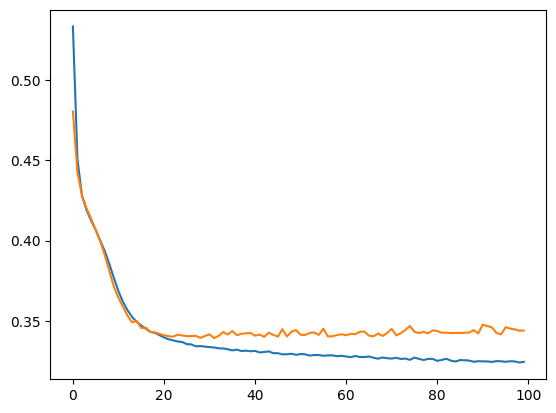

In [29]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

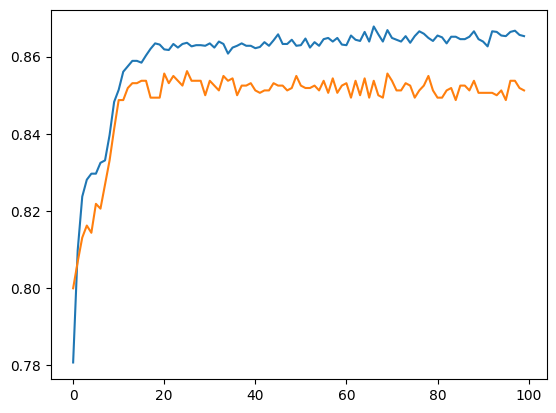

In [30]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])